In [1]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

## Monotonicity-Aware Lattice Architecture

The network combines a standard Deep Q-Network (DQN) with a monotone lattice component.

The overall Q-function is defined as

$$
Q(s,a)
=
Q_{\text{dqn}}(s,a)
+
Q_{\text{lattice}}(C,a),
$$

where

- $Q_{\text{dqn}}(s,a)$ is a standard unconstrained neural network,
- $Q_{\text{lattice}}(C,a)$ is a monotone lattice network depending on
  the remaining capacities $C=(C_1,\dots,C_K)$ and the action $a$.

---

### DQN Path

The first path processes the complete state vector

$$
[t, C_1,\dots,C_K,r,q_1,\dots,q_K]
$$

through a standard multilayer perceptron:

```text
Linear(256) → ReLU
→ Linear(256) → ReLU
→ Linear(128) → ReLU
→ Linear(output_dim)

## Monotonicity Penalty Loss

To encourage global monotonicity of the learned Q-function with respect to the remaining capacities, an additional monotonicity regularization term is added to the standard DQN loss.

The structural assumption of the DRAUSP is:

$$
C'_k \ge C_k \quad \forall k
$$

should imply

$$
Q(s',a) \ge Q(s,a)
$$

for all actions $a$, since having more remaining capacity should never decrease the expected future revenue.

---

### Construction of Monotone Comparison States

For every sampled state $s$ in a training batch, an additional comparison state $s'$ is generated.

The comparison state is constructed by increasing the remaining capacities:

$$
C'_k = C_k + 1
$$

while all other state components remain unchanged.

Thus, every original state produces exactly one monotone comparison state satisfying

$$
C' \ge C.
$$

This creates local monotonicity comparisons directly during training without requiring additional environment interactions.

---

### Monotonicity Penalty

The network evaluates both states:

$$
Q(s,a)
\quad\text{and}\quad
Q(s',a).
$$

Monotonicity violations occur whenever

$$
Q(s,a) > Q(s',a),
$$

despite \(s'\) having larger remaining capacities.

Such violations are penalized using the loss

$$
\mathcal{L}_{\text{mono}}
=
\operatorname{ReLU}
\left(
Q(s,a)-Q(s',a)
\right).
$$

The ReLU ensures that only actual violations contribute to the loss.

---

### Final Training Objective

The final optimization objective combines the standard temporal-difference loss with the monotonicity penalty:

$$
\mathcal{L}
=
\mathcal{L}_{\text{DQN}}
+
\lambda_{\text{mono}}
\mathcal{L}_{\text{mono}},
$$

where

- $\mathcal{L}_{\text{DQN}}$ is the standard Bellman loss,
- $\mathcal{L}_{\text{mono}}$ penalizes monotonicity violations,
- $\lambda_{\text{mono}}$ controls the strength of the regularization.

---

### Motivation

The lattice component alone only guarantees monotonicity for the lattice subnetwork itself.

Since the total Q-function additionally contains an unconstrained DQN component,

$$
Q(s,a)
=
Q_{\text{dqn}}(s,a)
+
Q_{\text{lattice}}(s,a),
$$

global monotonicity of the complete Q-values is not automatically guaranteed.

The monotonicity penalty therefore acts directly on the final Q-values and encourages the entire model to satisfy the desired structural property.

In [ ]:
# TODO: Track the errors to find a good value for lambda, combining the losses

In [4]:
from dqn_agent import DQNAgent
from lattice_dqn_withaction import LatticeDQNNetwork
agent = DQNAgent(env, QnetworkClass=LatticeDQNNetwork)

In [5]:
reward_history = agent.train(num_episodes=1000)

Episode   50/1000  Reward:   396.00  Avg(50):   438.40  ε: 0.778
Episode  100/1000  Reward:   372.00  Avg(50):   446.84  ε: 0.606
Episode  150/1000  Reward:   397.00  Avg(50):   453.32  ε: 0.471
Episode  200/1000  Reward:   549.00  Avg(50):   495.78  ε: 0.367
Episode  250/1000  Reward:   643.00  Avg(50):   549.92  ε: 0.286
Episode  300/1000  Reward:   588.00  Avg(50):   586.90  ε: 0.222
Episode  350/1000  Reward:   612.00  Avg(50):   620.16  ε: 0.173
Episode  400/1000  Reward:   654.00  Avg(50):   636.34  ε: 0.135
Episode  450/1000  Reward:   775.00  Avg(50):   679.22  ε: 0.105
Episode  500/1000  Reward:   734.00  Avg(50):   670.06  ε: 0.100
Episode  550/1000  Reward:   703.00  Avg(50):   695.70  ε: 0.100
Episode  600/1000  Reward:   723.00  Avg(50):   712.72  ε: 0.100
Episode  650/1000  Reward:   519.00  Avg(50):   734.00  ε: 0.100
Episode  700/1000  Reward:   734.00  Avg(50):   717.94  ε: 0.100
Episode  750/1000  Reward:   687.00  Avg(50):   717.36  ε: 0.100
Episode  800/1000  Reward

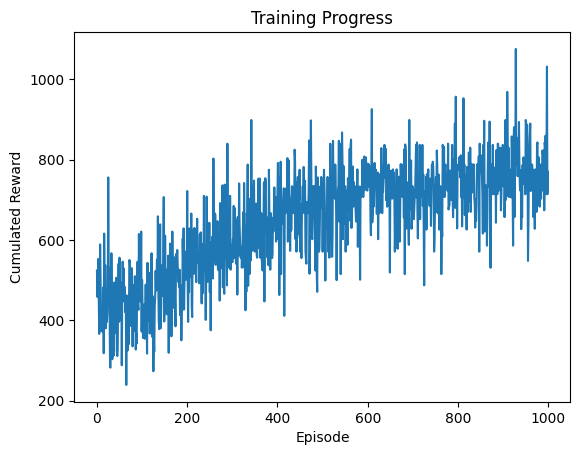

In [6]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.show()

In [7]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(state_t)
    q_total = net(state_t)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [266.32593 294.4692  291.2193  294.89294]
Bonus:   2.398
Q_total: [268.72366 296.86694 293.61703 297.29068]


Teste ob der Bonus einen wirklichen Einfluss hat

In [9]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(state_t)
    q_total = net(state_t)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Bonus:   {bonus.numpy().flatten()[1]:.3f}")
print(f"Bonus:   {bonus.numpy().flatten()[2]:.3f}")
print(f"Bonus:   {bonus.numpy().flatten()[3]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [266.32593 294.4692  291.2193  294.89294]
Bonus:   2.398
Bonus:   2.398
Bonus:   2.398
Bonus:   2.398
Q_total: [268.72366 296.86694 293.61703 297.29068]


Bonus erfüllt die Monotonieeigenschaft